In [1]:
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import os
import liana as li
from liana.method import cellphonedb, cellchat
from tqdm import tqdm
#liana dotplot returns a ggsave object...
from plotnine import ggsave, ggplot
import numpy as np
import warnings
warnings.filterwarnings("ignore")

In [2]:
folder = "IndividualMiceData/"
Mice = ["GF_HF_6B","GF_HF_13L","SPF_HF_118","SPF_HF_131","SPF_HF_133","GF_HFVHC_5A","GF_HFVHC_16L","SPF_HFVHC_124","SPF_HFVHC_136","SPF_HFVHC_137"]
method = ["CellPhoneDB", "CellChat"]
def get_data():
    data = {}
    for mouse in tqdm(Mice):
        data[mouse] = {}
        for m in method:
            file = folder+mouse+"_"+m+".h5ad"
            data[mouse][m] = sc.read_h5ad(file)
    return data
data = get_data()

100%|██████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:21<00:00,  2.12s/it]


In [7]:
def AnalysisOnOneMouse(data,index):
    mouse_curr = list(data.keys())[index]
    mouse_curr_data = {}
    for m in method:
        x = data[mouse_curr][m].uns["cpdb_res"]
        if m == 'CellPhoneDB':
            # x = x[x['lr_means'] != 0]
            x = x[x['cellphone_pvals'] < 0.05]
        else:
            # x = x[x['lr_probs'] != 0]
            x = x[x['cellchat_pvals'] < 0.05]
        x = x[['ligand', 'receptor', 'source','target']]
        x['Source -> Target'] = x['source'] + ' -> ' + x['target']
        x['Ligand -> Receptor'] = x['ligand'] + ' -> ' + x['receptor'] 
        mouse_curr_data[m] = x[['Source -> Target', 'Ligand -> Receptor']]

    # Group by 'Source -> Target' in df1 and get unique 'Ligand -> Receptor' counts
    df1_grouped = mouse_curr_data[method[0]].groupby('Source -> Target')['Ligand -> Receptor'].nunique().reset_index(name=method[0])
    
    # Group by 'Source -> Target' in df2 and get unique 'Ligand -> Receptor' counts
    df2_grouped = mouse_curr_data[method[1]].groupby('Source -> Target')['Ligand -> Receptor'].nunique().reset_index(name=method[1])
    
    # Merge the grouped DataFrames on 'Source -> Target'
    df_merged = pd.merge(df1_grouped, df2_grouped, on='Source -> Target', how='outer').fillna(0)
    
    # Function to find common and different 'Ligand -> Receptor' within each 'Source -> Target' group
    def analyze_lr(group1, group2):
        set1 = set(group1)
        set2 = set(group2)
        common = len(set1.intersection(set2))
        diff1 = len(set1 - set2)
        diff2 = len(set2 - set1)
        a = 'Different in ' + method[0]
        b = 'Different in ' + method[1]
        return pd.Series({'Common': common, a: diff1, b: diff2})
    
    # Group by 'Source -> Target' and apply the analysis function
    df_analysis = pd.concat([mouse_curr_data[method[0]].groupby('Source -> Target')['Ligand -> Receptor'].unique().rename('LRs DF1'),
                             mouse_curr_data[method[1]].groupby('Source -> Target')['Ligand -> Receptor'].unique().rename('LRs DF2')], axis=1).fillna('').apply(lambda x: analyze_lr(x['LRs DF1'], x['LRs DF2']), axis=1).reset_index()
    
    # Final Merged DataFrame
    df_new = pd.merge(df_merged, df_analysis, on='Source -> Target', how='outer').fillna(0)
    df_new['CellPhoneDB'] = round(df_new['Common']/df_new['CellPhoneDB'],2)
    df_new['CellChat'] = round(df_new['Common']/df_new['CellChat'],2)
    df_new = df_new[['Source -> Target', 'CellPhoneDB', 'CellChat']]
    print(mouse_curr)
    return df_new

In [8]:
d = {}
for i in range(10):
    m = list(data.keys())[i]
    d[m] = AnalysisOnOneMouse(data,i)

GF_HF_6B
GF_HF_13L
SPF_HF_118
SPF_HF_131
SPF_HF_133
GF_HFVHC_5A
GF_HFVHC_16L
SPF_HFVHC_124
SPF_HFVHC_136
SPF_HFVHC_137


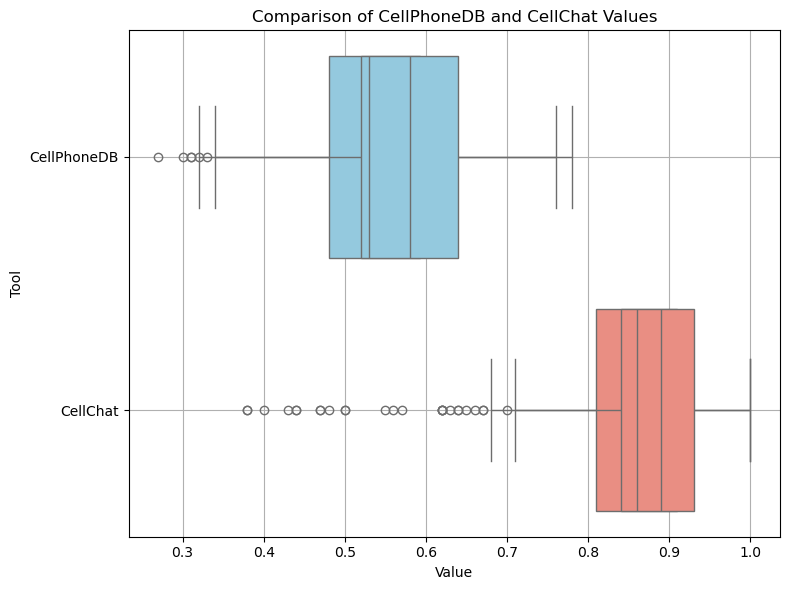

In [16]:
# Melt the DataFrame to have 'Tool' and 'Value' columns
df_melted1 = d['GF_HF_6B'].melt(value_vars=['CellPhoneDB', 'CellChat'], var_name='Tool', value_name='Value')
df_melted2 = d['GF_HF_13L'].melt(value_vars=['CellPhoneDB', 'CellChat'], var_name='Tool', value_name='Value')

# Create the box plot using Seaborn
plt.figure(figsize=(8, 6))
sns.boxplot(y='Tool', x='Value', data=df_melted1, palette={'CellPhoneDB': 'skyblue', 'CellChat': 'salmon'})
sns.boxplot(y='Tool', x='Value', data=df_melted2, palette={'CellPhoneDB': 'skyblue', 'CellChat': 'salmon'})
plt.ylabel('Tool')
plt.xlabel('Value')
plt.title('Comparison of CellPhoneDB and CellChat Values')
plt.grid(True)
plt.tight_layout()

# Save the plot
# plt.savefig('cellphonedb_cellchat_boxplot.png')

# Display the plot
plt.show()

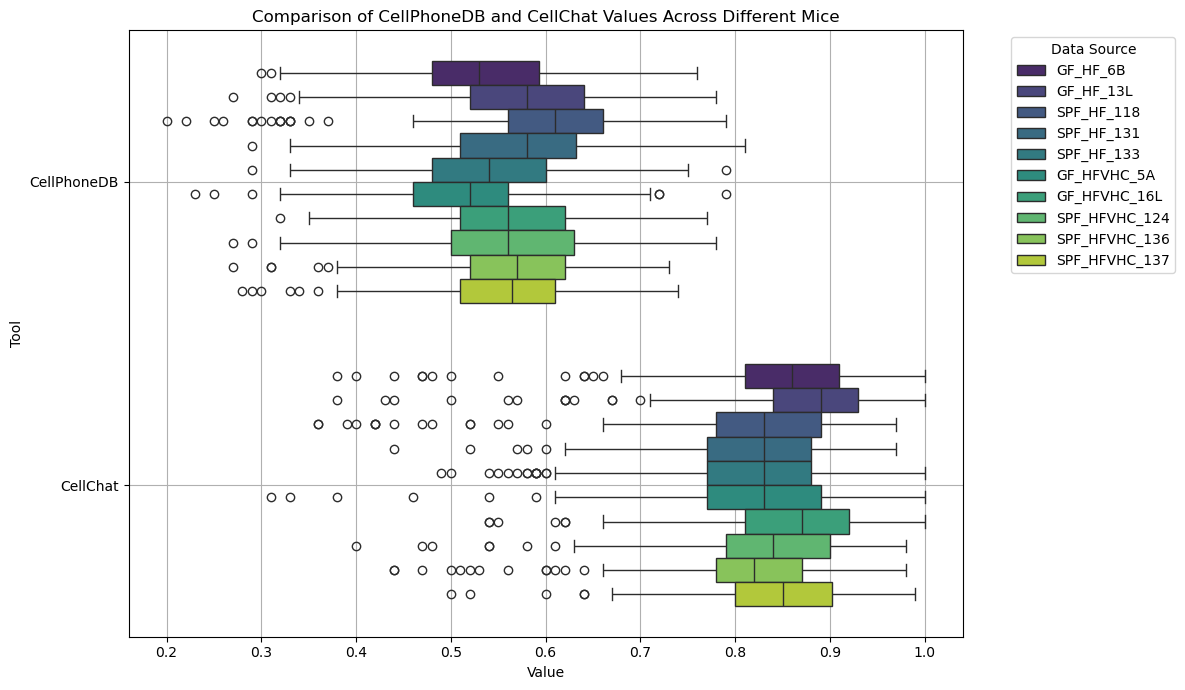

In [18]:
dataframes = []
for i in range(10):
    m = list(data.keys())[i]
    df = pd.DataFrame(d[m])
    df['DataSource'] = m
    dataframes.append(df)

# --- Combine all DataFrames ---
df_combined = pd.concat(dataframes, ignore_index=True)

# --- Melt the combined DataFrame ---
df_melted_combined = df_combined.melt(
    id_vars='DataSource',
    value_vars=['CellPhoneDB', 'CellChat'],
    var_name='Tool',
    value_name='Value'
)

# --- Create the combined box plot with color coding for 'DataSource' ---
plt.figure(figsize=(12, 7))
sns.boxplot(y='Tool', x='Value', hue='DataSource', data=df_melted_combined, palette='viridis')
plt.ylabel('Tool')
plt.xlabel('Value')
plt.title(f'Comparison of CellPhoneDB and CellChat Values Across Different Mice')
plt.grid(True)
plt.legend(title='Data Source', bbox_to_anchor=(1.05, 1), loc='upper left') # Adjust legend position
plt.tight_layout()

# Save the combined plot
plt.savefig(f'combined_cellphonedb_cellchat_boxplot_across_mice.png')

# Display the combined plot
# plt.show()